# Sensitivity of the evidence rule: bin alignment, dilation radius, absolute floor and acquisition

`part_0_2` selected a relative threshold with the dilation radius held at its configured
value, the absolute floor at zero and the population pooled over acquisitions. This
notebook tests all three of those held-fixed choices: whether annotated m/z values
actually land on the bin carrying their peak, how much the dilation radius changes the
selected threshold's effect, whether an absolute floor would do anything the relative
rule does not, and whether the selection survives being applied inside each source
acquisition separately.

The last question is the one that can invalidate `part_0_2` outright: the campaign's
split assigns whole acquisitions to train, validation and test, so a threshold whose
effect differs strongly between acquisitions produces partitions trained and evaluated
under different label semantics.

## Introduction

The evidence rule has three parameters, and `part_0_2` fixed two of them by
configuration rather than by evidence. `bin_radius` decides how many neighbouring bins
the intensity may be drawn from, which is a statement about how precisely an annotated
m/z can be located on a 0.55 Da grid. `absolute_threshold` decides whether there is an
intensity floor below which everything is negative regardless of the pixel's own scale,
which is a statement about whether the relative rule behaves consistently across pixels
of very different dynamic range. Neither is a free hyperparameter to be tuned for
performance; both encode assumptions about the measurement that can be checked directly.

The alignment question comes first because it is prior to the others. If annotated m/z
values systematically land one bin away from the peak they refer to, then a radius of
zero measures background at the mapped bin and declares negatives for ions that are
plainly present one bin over — a labelling error that no threshold can repair, and the
reason the `bin_radius` parameter exists at all.

### Assumptions

- **The unannotated population is a usable null for alignment.** Where no real peak sits
  at an ion, the strongest bin inside the annotation window is placed by noise, so its
  displacement distribution should be close to uniform. That makes it the reference the
  annotated displacement distribution is compared against. The null is not exactly
  uniform — a neighbouring real peak can leak into the window — so only a clear excess
  is interpreted.
- **The displacement is measured in the widest window the pass covered**, $\rho = 2$,
  i.e. five bins, and reported relative to the ion's first mapped bin. Every ion in this
  cohort maps to exactly one bin, so that is the mapped bin itself.
- **Acquisition is identified by `dataset_id`**, the same field the campaign's split uses
  as `group_fields`, resolved through the annotation reader.
- Population, preprocessing and the $\alpha = 0$ convention as in `part_0_1` and
  `part_0_2`.

### Notation

Extends `part_0_1` and `part_0_2`. Additionally:

- $\rho$ — dilation radius, in bins; $d$ — displacement of the strongest bin inside the
  annotation window from the mapped bin, in bins, $d \in \{-2,\dots,2\}$.
- $\alpha$ — the absolute threshold, on the TIC-normalized intensity scale.
- $g$ — one source acquisition; $\mathrm{yield}_g(\beta)$ — negative yield computed
  inside acquisition $g$.

## Configuration

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.evidence import EvidenceStatistics
from msi_autoencoder_wrapper.analysis.autoencoder.evidence import alignment_analysis as alignment
from msi_autoencoder_wrapper.analysis.autoencoder.evidence import threshold_analysis as thresholds
from msi_autoencoder_wrapper.analysis.autoencoder.evidence import views
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_metric_distribution

logger = get_custom_logger("evidence_rule_sensitivity")

2026-09-07 23:26:42,631 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-07 23:26:42,634 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


In [2]:
EVIDENCE_CACHE = Path("data/kidney_workspace/cache/evidence/predictive_heads_initial_full.npz")
ARTIFACT_DIR = Path(
    "assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/"
    "part_0_3_evidence_rule_sensitivity_results"
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CONFIGURED_BIN_RADIUS = 1
CONFIGURED_THRESHOLDS = (0.005, 0.01)
CANDIDATE_THRESHOLDS = (0.001, 0.002, 0.005, 0.01, 0.02, 0.05)
CANDIDATE_ABSOLUTE = (1e-6, 1e-5, 1e-4, 1e-3)
CONTRADICTION_TOLERANCE = 0.01
BIN_STEP = 0.55

theme = resolve_theme(None)
theme.apply()

statistics = EvidenceStatistics.load(EVIDENCE_CACHE)
print(f"population: {statistics.spectrum_count} pixels x {statistics.class_count} ions")
print(f"measured dilation radii: {statistics.bin_radii}")

population: 420649 pixels x 508 ions
measured dilation radii: (0, 1, 2)


## Annotation-to-bin alignment

### Methodology

#### Theoretical

Two independent checks, one geometric and one empirical.

The geometric check uses no spectra at all. Each ion's annotated m/z is compared against
the centre of the bin the binner maps it to; the signed distance, expressed in bin
widths, must lie within $\pm\tfrac{1}{2}$ by construction and should be roughly uniform
inside that interval if the mapping is doing nothing but rounding. A systematic
displacement of the whole distribution would indicate a mapping offset, which no
dilation radius can repair because it would move every ion the same way.

The empirical check asks where the intensity actually is. For each annotated entry, the
displacement $d$ of the strongest bin within $\pm 2$ bins of the mapped bin is recorded,
and the same distribution is accumulated over unannotated entries. The unannotated
distribution is the null described in the assumptions. The quantity of interest is the
*excess*, $\Pr(d \mid A) - \Pr(d \mid \bar{A})$: a sharp positive excess at $d = 0$
confirms the mapping; an excess concentrated at $d = \pm 1$ is a calibration offset that
$\rho \ge 1$ absorbs and $\rho = 0$ converts into false negatives.

#### Implementation

Both quantities come from the population pass. The geometric offset is computed from the
reader's annotation m/z and the binner's own axis, so it reproduces the mapping the
dataset performed rather than re-deriving it. The empirical displacement is the
`argmax` over a five-bin window gathered around the mapped bin, restricted to entries
whose window carries nonzero intensity — a window that is entirely zero has an arbitrary
`argmax`, and including those entries would flatten both distributions toward the
uniform and hide the effect. Per-ion displacement distributions are retained so that
individually misaligned ions can be identified, not only a cohort-level shift.

#### Figure descriptions

The first figure is a histogram of the geometric offset: the x-axis is the signed
distance from the annotated m/z to its bin centre, in bin widths, and the y-axis the
number of ions. It involves no spectra.

The second figure has the displacement $d$ in bins on the x-axis and, on the y-axis, the
share of informative entries whose strongest bin sits at that displacement. Blue bars
are annotated entries, red bars unannotated ones — the null. Bars are drawn side by
side, not stacked; they are shares within their own population, so the two sets each sum
to one. An excess of blue over red at $d = 0$ supports the mapping; an excess at
$d \ne 0$ is a systematic offset.

### Remarks

- The geometric mapping is sound: offsets are centred on zero (mean $-0.012$ bins) and
  bounded by half a bin width, i.e. pure rounding with no systematic shift.
- The empirical picture is only partly consistent with that. Displacement zero carries a
  clear excess (64.0 % of annotated entries against a 39.9 % null, $+24.2$ points), but
  147 of 508 ions place their strongest bin dominantly off-centre, several almost
  deterministically — `C19H22O4|-H` at $d = -2$ in 99.7 % of its informative entries with
  a centre share of exactly zero, `C50H82NO10P|-H` likewise at 99.96 %. A radius of 1
  does not reach $d = \pm 2$, so for those ions the configured rule reads a position the
  peak is never at.
- The unannotated null is not uniform (0.29 / 0.09 / 0.40 / 0.11 / 0.11), and its own
  mode is at $d = 0$. Ion bin positions are peak-carrying positions whether or not the
  ion is annotated there, which is the same conclusion the distribution comparison in
  `part_0_2` reached from a different measurement.

### Notes

2026-09-07 23:26:43,240 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.alignment_analysis:63 | Resolved the mapped-bin geometry of 508 ion(s).


ions with a resolvable annotated m/z: 508/508
offset in bins: mean=-0.0120, median=-0.0205, min=-0.5064, max=0.4970


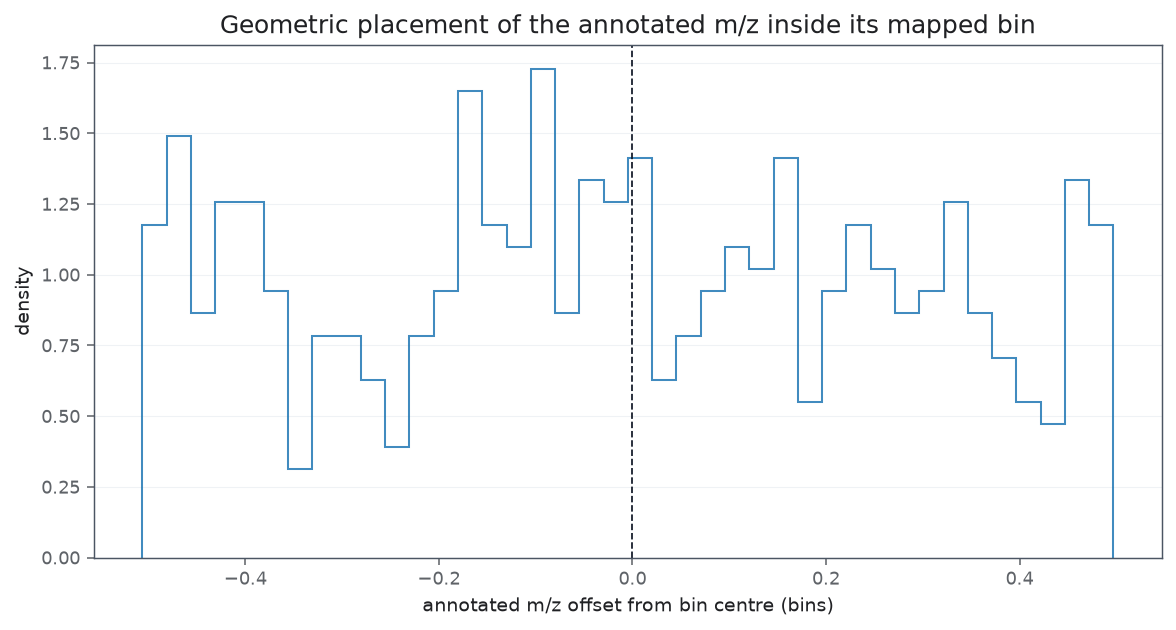

In [3]:
geometry = pd.DataFrame(alignment.bin_offset_records(statistics, bin_step=BIN_STEP))
geometry.to_csv(ARTIFACT_DIR / "bin_offset_geometry.csv", index=False)

figure, axis = plt.subplots(figsize=(8.5, 4.6), dpi=theme.figure_dpi)
plot_metric_distribution(
    geometry["offset_bins"].to_numpy(), metric="annotated m/z offset from bin centre (bins)",
    ax=axis, bins=40, kind="histogram", theme=theme, histtype="step",
)
axis.axvline(0.0, color=theme.baseline_color, linestyle=theme.baseline_line_style,
             linewidth=theme.reference_line_width)
axis.set_title("Geometric placement of the annotated m/z inside its mapped bin")
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "bin_offset_geometry.png")

print(f"ions with a resolvable annotated m/z: {len(geometry)}/{statistics.class_count}")
print(f"offset in bins: mean={geometry['offset_bins'].mean():.4f}, "
      f"median={geometry['offset_bins'].median():.4f}, "
      f"min={geometry['offset_bins'].min():.4f}, max={geometry['offset_bins'].max():.4f}")

,offset_bins,annotated_entries,unannotated_entries,annotated_share,unannotated_share,excess_over_unannotated
0,-2,2163516.0,47173430.0,0.20620,0.28571,-0.07951
1,-1,492679.0,15060130.0,0.04696,0.09121,-0.04426
2,0,6719608.0,65831524.0,0.64043,0.39871,0.24172
3,1,511997.0,18188769.0,0.04880,0.11016,-0.06136
4,2,604498.0,18857363.0,0.05761,0.11421,-0.05660


2026-09-07 23:26:43,817 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.alignment_analysis:136 | Measured peak displacement for 508 ion(s); 147 place their strongest bin off-centre.


ions whose strongest bin is dominantly off-centre: 147/508


,class_name,mz,informative_entries,dominant_offset,dominant_share,centre_share
142,C19H22O4|-H,313.1445,133817.0,-2,0.9969,0.0000
175,C20H34O2|-H,305.2486,88068.0,-2,0.8691,0.0183
326,C39H78NO8P|-H,718.5392,84055.0,2,0.6864,0.3006
371,C43H78NO7P|-H,750.5443,81896.0,2,0.6391,0.3346
477,C50H82NO10P|-H,886.5604,81048.0,-2,0.9996,0.0000
374,C43H79O13P|-H,833.5186,80709.0,2,0.5106,0.4821
422,C46H76NO10P|-H,832.5134,79545.0,1,0.9599,0.0346
417,C45H81O13P|-H,859.5342,79332.0,-2,0.9020,0.0697
2,C10H13N4O8P|-H,347.0398,78536.0,-2,0.6550,0.0403
347,C41H80NO8P|-H,744.5549,78301.0,1,0.4877,0.1186


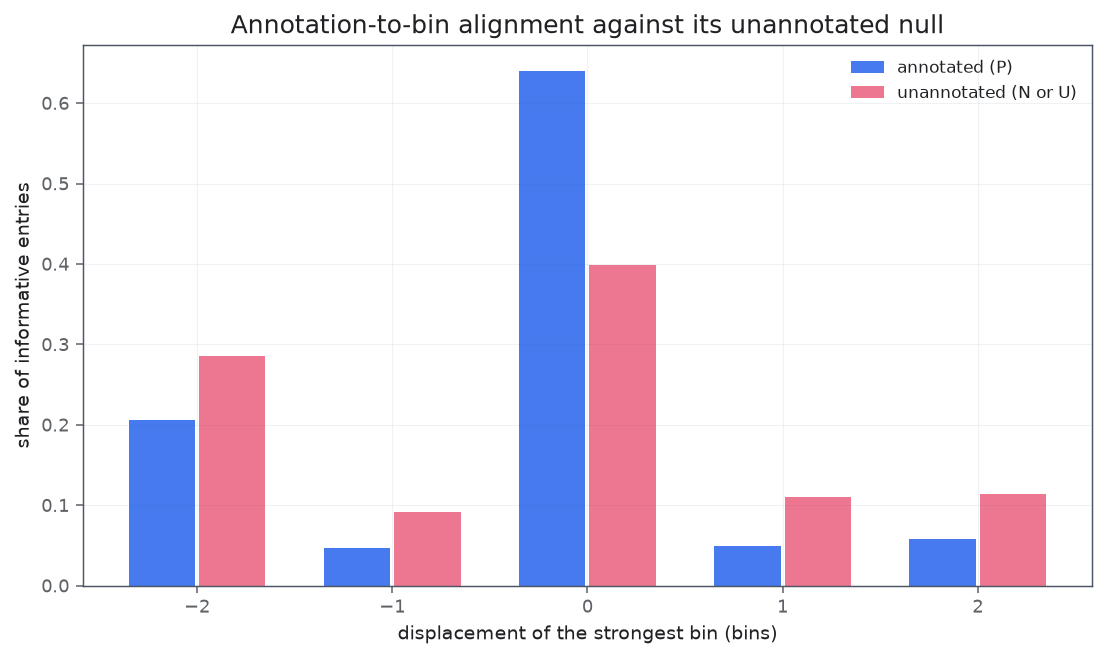

In [4]:
displacement = pd.DataFrame(alignment.peak_displacement_records(statistics))
displacement.to_csv(ARTIFACT_DIR / "peak_displacement.csv", index=False)

figure, axis = plt.subplots(figsize=(8.0, 4.8), dpi=theme.figure_dpi)
views.plot_peak_displacement(displacement.to_dict("records"), ax=axis, theme=theme)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "peak_displacement.png")
display(displacement.round(5))

per_class = pd.DataFrame(alignment.class_displacement_records(statistics))
per_class.to_csv(ARTIFACT_DIR / "class_displacement.csv", index=False)
print(f"ions whose strongest bin is dominantly off-centre: "
      f"{int((per_class['dominant_offset'] != 0).sum())}/{len(per_class)}")
display(per_class[per_class["dominant_offset"] != 0].nlargest(10, "informative_entries")[
    ["class_name", "mz", "informative_entries", "dominant_offset", "dominant_share", "centre_share"]
].round(4))

## Effect of the dilation radius on the selected threshold

### Methodology

#### Theoretical

Widening the window can only increase $s_{ic}$, so for a fixed $\beta$ a larger $\rho$
can only decrease the negative yield and can only decrease the contradiction rate. The
question is not the direction but the magnitude, and it has a clear reading. If moving
from $\rho = 0$ to $\rho = 1$ removes a substantial share of the negatives, then those
negatives were entries whose peak sat one bin off the mapped position — exactly the
labelling error the alignment section looks for, seen from the other side. If the two
radii give nearly the same curves, the dilation is doing nothing and the mapping is
already precise.

The same selection rule as in `part_0_2` is applied at each radius, so the comparison is
between *selected operating points*, not between arbitrary fixed thresholds: a radius
that permits a larger threshold at the same contradiction tolerance is genuinely
recovering evidence rather than merely shifting the axis.

#### Implementation

All three radii were accumulated in the same population pass, over the same pixels and
the same reads, so the curves differ only in the pooling window and no re-reading or
resampling is involved. `recommend_threshold` is applied per radius at the tolerance
fixed in `part_0_2`.

#### Figure descriptions

Two panels sharing an x-axis, the relative threshold $\beta$ on a logarithmic scale. The
left panel's y-axis is the share of unannotated entries turned into operational
negatives; the right panel's y-axis is the share of annotated entries at or below the
threshold. Colour encodes the dilation radius, sampled across the sequential colormap,
darker meaning wider; the three curves are directly comparable because they are the same
measurement on the same population. Vertical separation between curves at a fixed
$\beta$ is the amount of evidence the extra bins contribute.

### Remarks

- The radius matters most for the cost, not the yield: at the configured
  $\beta = 0.005$ the contradiction rate falls from 1.82 % ($\rho = 0$) to 0.85 %
  ($\rho = 1$) to 0.62 % ($\rho = 2$), while the yield falls from 35.6 % to 28.7 % to
  22.8 %.
- At a matched 1 % tolerance the three radii end up close: selected thresholds 0.0030 /
  0.0053 / 0.0060 for yields of 32.7 % / 29.3 % / 24.6 %. Widening the window therefore
  buys accuracy at a real but moderate cost in negatives, and $\rho = 0$ is not
  strictly worse — it reaches a slightly higher yield at the same tolerance.

### Notes

2026-09-07 23:26:44,111 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 247 relative threshold(s) at bin_radius=0.


2026-09-07 23:26:44,122 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 247 relative threshold(s) at bin_radius=1.


2026-09-07 23:26:44,132 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 247 relative threshold(s) at bin_radius=2.


2026-09-07 23:26:45,034 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 247 relative threshold(s) at bin_radius=0.


2026-09-07 23:26:45,035 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:472 | Selected relative_threshold=0.002985382619 at bin_radius=0 (contradiction=0.0097, negative yield=0.3272).


...

2026-09-07 23:26:45,055 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 2 relative threshold(s) at bin_radius=1.


2026-09-07 23:26:45,071 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 247 relative threshold(s) at bin_radius=2.


2026-09-07 23:26:45,074 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:472 | Selected relative_threshold=0.005956621435 at bin_radius=2 (contradiction=0.0093, negative yield=0.2455).


2026-09-07 23:26:45,075 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 2 relative threshold(s) at bin_radius=2.


,bin_radius,selected_relative_threshold,selected_negative_fraction,selected_negative_to_positive,negative_fraction_at_0.005,negative_fraction_at_0.01,contradiction_at_0.005,contradiction_at_0.01
0,0,0.00299,0.32720,6.33451,0.35603,0.44471,0.01820,0.05326
1,1,0.00531,0.29255,5.66364,0.28708,0.37269,0.00846,0.03455
2,2,0.00596,0.24553,4.75344,0.22842,0.31199,0.00621,0.02805


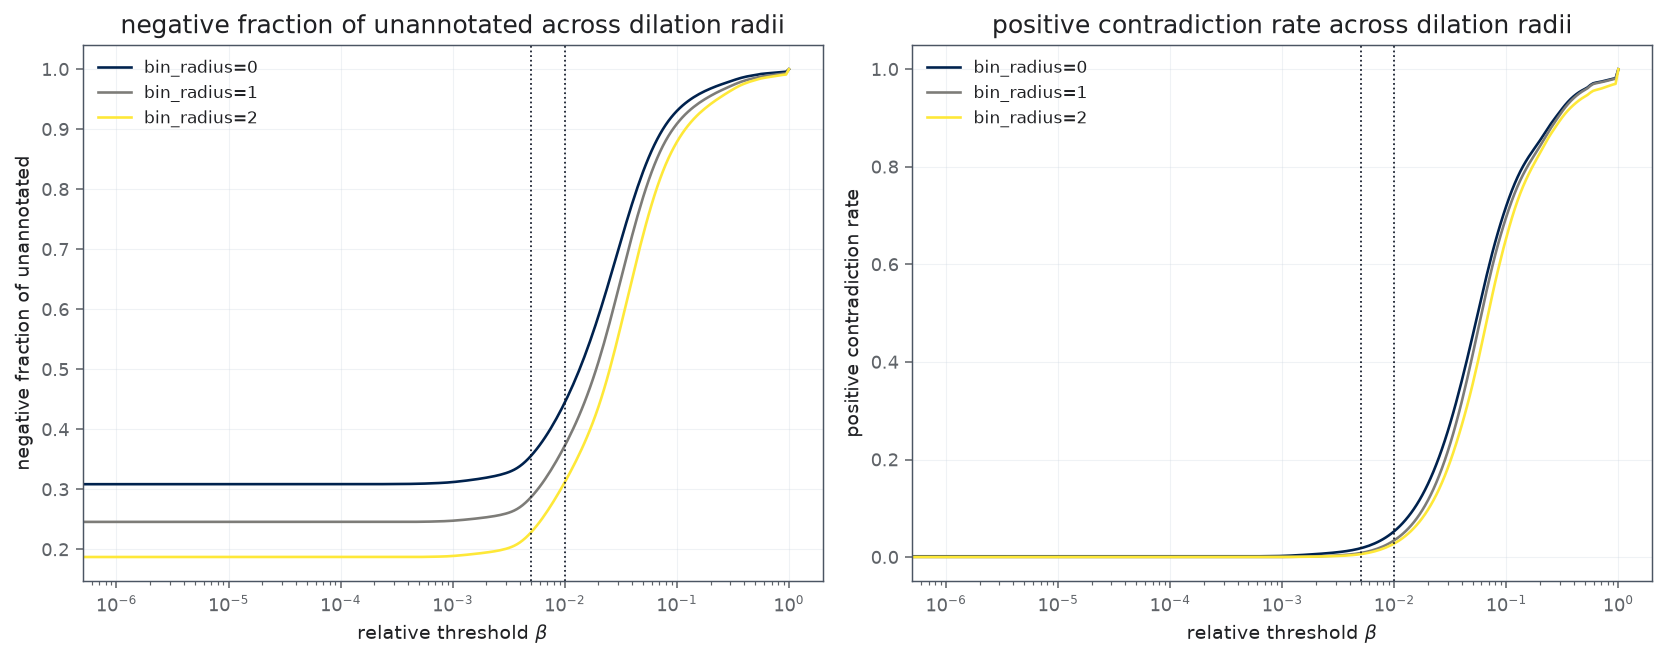

In [5]:
sweeps = {
    radius: thresholds.state_yield_records(statistics, bin_radius=radius)
    for radius in statistics.bin_radii
}
radius_frame = pd.concat([pd.DataFrame(records) for records in sweeps.values()], ignore_index=True)
radius_frame.to_csv(ARTIFACT_DIR / "radius_sweeps.csv", index=False)

figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), dpi=theme.figure_dpi, sharex=True)
views.plot_radius_sweeps(sweeps, metric="negative_fraction_of_unannotated", ax=axes[0], theme=theme)
views.plot_radius_sweeps(sweeps, metric="positive_contradiction_rate", ax=axes[1], theme=theme)
for axis in axes:
    for threshold in CONFIGURED_THRESHOLDS:
        axis.axvline(threshold, color=theme.baseline_color, linestyle=":", linewidth=theme.reference_line_width)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "radius_sweeps.png")

radius_rows = []
for radius in statistics.bin_radii:
    selected = thresholds.recommend_threshold(
        statistics, bin_radius=radius, maximum_contradiction_rate=CONTRADICTION_TOLERANCE,
    )
    at_configured = pd.DataFrame(thresholds.state_yield_records(
        statistics, bin_radius=radius, thresholds=CONFIGURED_THRESHOLDS,
    ))
    radius_rows.append({
        "bin_radius": radius,
        "selected_relative_threshold": selected["relative_threshold"],
        "selected_negative_fraction": selected["negative_fraction_of_unannotated"],
        "selected_negative_to_positive": selected["negative_to_positive_ratio"],
        **{
            f"negative_fraction_at_{threshold}": float(
                at_configured.loc[at_configured["relative_threshold"] == threshold,
                                  "negative_fraction_of_unannotated"].iloc[0]
            )
            for threshold in CONFIGURED_THRESHOLDS
        },
        **{
            f"contradiction_at_{threshold}": float(
                at_configured.loc[at_configured["relative_threshold"] == threshold,
                                  "positive_contradiction_rate"].iloc[0]
            )
            for threshold in CONFIGURED_THRESHOLDS
        },
    })
radius_summary = pd.DataFrame(radius_rows)
radius_summary.to_csv(ARTIFACT_DIR / "radius_selection.csv", index=False)
display(radius_summary.round(5))

## The absolute floor as an alternative and as a correction

### Methodology

#### Theoretical

Two distinct questions about $\alpha$, which the configuration currently fixes at zero.

*As an alternative parameterization*: with $\beta = 0$ the rule becomes a plain intensity
cut on the TIC-normalized scale, $s_{ic} \le \alpha$. Its yield and contradiction curves
are measured the same way as the relative ones, so the two parameterizations can be
compared at matched contradiction rates rather than argued about in principle.

*As a floor on top of the relative rule*: since $\tau_i = \max(\alpha, \beta \max_b x_{ib})$,
the floor binds only in pixels whose maximum falls below $\alpha / \beta$. That share is
a property of the per-pixel maxima alone and is computed exactly. If it is negligible,
adding $\alpha$ changes nothing and the parameter can stay at zero; if it is
substantial, the relative rule is behaving differently in weak and strong pixels and the
floor is doing real work.

The related question — whether the relative evidence itself depends on the pixel's
dynamic range — is answered by stratifying the unannotated population by its spectrum
maximum and recomputing the yield inside each stratum. A scale-free rule would give a
flat profile across strata.

#### Implementation

The absolute sweep reads the absolute-evidence histograms accumulated in the same pass,
on a logarithmic grid spanning $10^{-8}$ to $1$. The floor-binding share is computed
from the retained per-pixel maxima directly, with no histogram, so it is exact. The
stratified yield reads the joint histogram of relative evidence and spectrum maximum
accumulated over unannotated entries; strata are the maximum-axis buckets of that
histogram, and empty strata are omitted.

#### Figure descriptions

The first figure has the relative threshold $\beta$ on a logarithmic x-axis and the
negative yield on the y-axis, with one line per spectrum-maximum stratum, coloured
across the sequential colormap from the weakest to the strongest stratum. Lines lying on
top of each other mean the relative rule is scale-free; a systematic fan means it is not,
and the direction of the fan says whether weak or strong pixels yield more negatives.

The table beneath reports, per candidate $\alpha$, the pixel maximum below which the
floor binds and the share of pixels below it, at the threshold selected in `part_0_2`.

### Remarks

### Notes

In [6]:
absolute_sweep = pd.DataFrame(thresholds.absolute_threshold_records(statistics, bin_radius=CONFIGURED_BIN_RADIUS))
absolute_sweep.to_csv(ARTIFACT_DIR / "absolute_sweep.csv", index=False)

recommendation = thresholds.recommend_threshold(
    statistics, bin_radius=CONFIGURED_BIN_RADIUS, maximum_contradiction_rate=CONTRADICTION_TOLERANCE,
)
SELECTED_THRESHOLD = float(recommendation["relative_threshold"])

matched = absolute_sweep[absolute_sweep["positive_contradiction_rate"] <= CONTRADICTION_TOLERANCE]
best_absolute = matched.nlargest(1, "absolute_threshold")
print(f"relative rule at tolerance {CONTRADICTION_TOLERANCE}: beta={SELECTED_THRESHOLD:.6g}, "
      f"negative yield={recommendation['negative_fraction_of_unannotated']:.4f}")
if len(best_absolute):
    row = best_absolute.iloc[0]
    print(f"absolute rule at the same tolerance: alpha={row['absolute_threshold']:.6g}, "
          f"negative yield={row['negative_fraction_of_unannotated']:.4f}")

floor = pd.DataFrame(thresholds.absolute_floor_records(
    statistics, relative_threshold=SELECTED_THRESHOLD, absolute_thresholds=CANDIDATE_ABSOLUTE,
))
floor.to_csv(ARTIFACT_DIR / "absolute_floor.csv", index=False)
display(floor.round(8))

2026-09-07 23:26:45,838 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:118 | Swept 247 relative threshold(s) at bin_radius=1.


2026-09-07 23:26:45,839 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.threshold_analysis:472 | Selected relative_threshold=0.005308844442 at bin_radius=1 (contradiction=0.0096, negative yield=0.2925).


relative rule at tolerance 0.01: beta=0.00530884, negative yield=0.2925
absolute rule at the same tolerance: alpha=0.000421697, negative yield=0.2740


,relative_threshold,absolute_threshold,maximum_crossover,pixels_with_binding_floor_fraction,pixels_with_binding_floor
0,0.005309,0.000001,0.000188,0.000000,0
1,0.005309,0.000010,0.001884,0.000000,0
2,0.005309,0.000100,0.018836,0.014535,6114
3,0.005309,0.001000,0.188365,0.975773,410458


relative_threshold,0.001,0.002,0.005,0.010,0.020,0.050
maximum_upper,,,,,,
0.015849,0.0000,0.0000,0.0000,0.0000,0.0014,0.2035
0.016788,0.0000,0.0000,0.0000,0.0001,0.0030,0.2562
0.017783,0.0000,0.0000,0.0000,0.0001,0.0042,0.3063
0.018836,0.0000,0.0000,0.0000,0.0002,0.0065,0.3541
0.019953,0.0000,0.0000,0.0000,0.0002,0.0092,0.4034
0.021135,0.0000,0.0000,0.0001,0.0004,0.0130,0.4554
0.022387,0.0000,0.0000,0.0000,0.0005,0.0189,0.5095
0.023714,0.0001,0.0001,0.0001,0.0008,0.0272,0.5633
0.025119,0.0000,0.0000,0.0001,0.0011,0.0388,0.6122


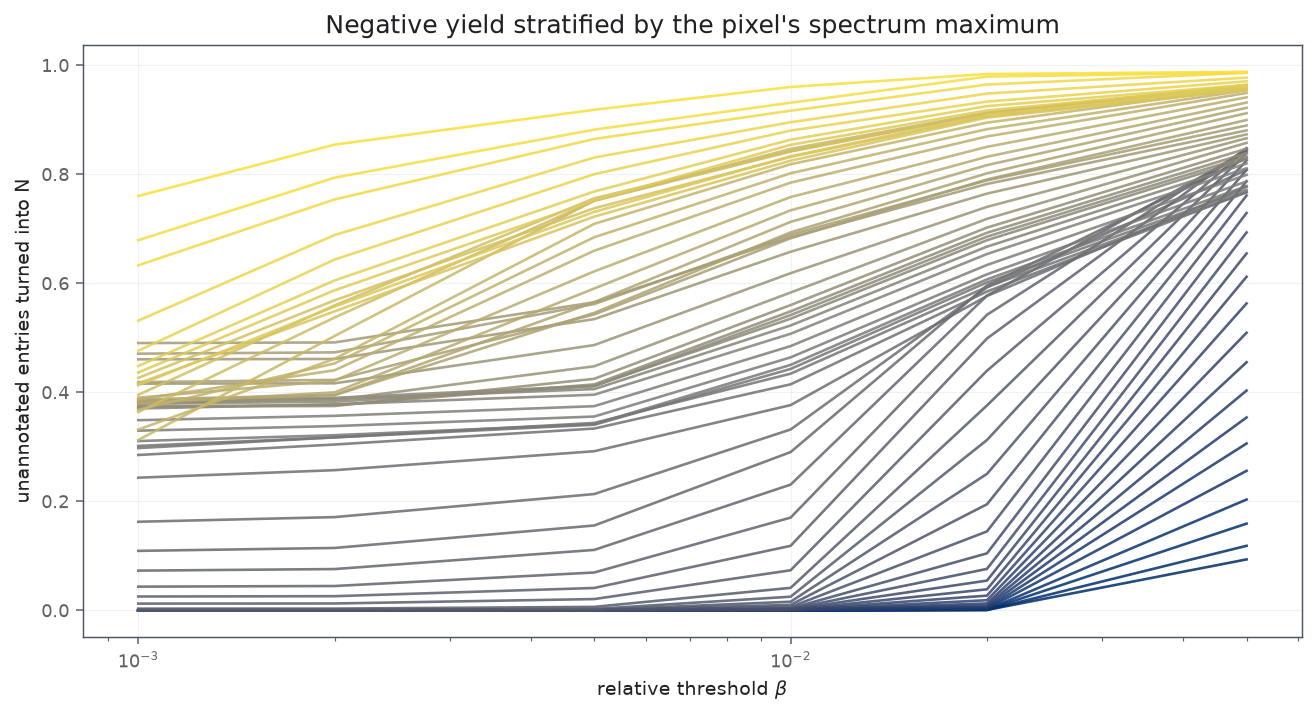

In [7]:
stratified = pd.DataFrame(thresholds.relative_by_maximum_records(
    statistics, bin_radius=CONFIGURED_BIN_RADIUS, thresholds=CANDIDATE_THRESHOLDS,
))
stratified.to_csv(ARTIFACT_DIR / "maximum_stratified_yield.csv", index=False)

strata = sorted(stratified["maximum_upper"].unique())
colors = [plt.get_cmap(theme.image_colormap)(index / max(len(strata) - 1, 1)) for index in range(len(strata))]
figure, axis = plt.subplots(figsize=(9.5, 5.2), dpi=theme.figure_dpi)
for color, upper in zip(colors, strata):
    rows = stratified[stratified["maximum_upper"] == upper].sort_values("relative_threshold")
    if rows["unannotated_entries"].iloc[0] < 1e4:
        continue
    axis.plot(rows["relative_threshold"], rows["negative_fraction_of_unannotated"],
              color=color, linewidth=theme.line_width, alpha=theme.primary_alpha)
axis.set(xscale="log", xlabel=r"relative threshold $\beta$",
         ylabel="unannotated entries turned into N",
         title="Negative yield stratified by the pixel's spectrum maximum")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "maximum_stratified_yield.png")

pivot = stratified.pivot_table(
    index="maximum_upper", columns="relative_threshold", values="negative_fraction_of_unannotated"
)
sizes = stratified.groupby("maximum_upper")["unannotated_entries"].first()
display(pivot[sizes > 1e5].round(4))

## Stability of the selected threshold across source acquisitions

### Methodology

#### Theoretical

The campaign splits by `dataset_id`, so an acquisition never straddles two partitions.
That makes any acquisition-level variation in the rule's behaviour a between-partition
variation as well. Two quantities are recomputed inside each acquisition at the selected
threshold: the negative yield $\mathrm{yield}_g(\beta)$ and the contradiction rate. A
wide spread in the first means the partitions differ in how many operational negatives
they contain, which changes the effective class balance a P/N objective sees between
training and evaluation. A wide spread in the second means the rule is trustworthy in
some acquisitions and not in others, which is the more serious of the two because it is
a validity problem rather than a calibration one.

#### Implementation

Per-acquisition histograms accumulated during the same population pass, keyed by the
`dataset_id` resolved through the annotation reader's bulk metadata API. The sweep is the
same cumulative-count operation as the pooled one and is therefore equally exact inside
each acquisition. Acquisitions differ by three orders of magnitude in pixel count, so
counts are reported alongside the shares.

#### Figure descriptions

The x-axis is the relative threshold $\beta$ on a logarithmic scale; the y-axis is the
negative yield computed inside one acquisition. Each thin grey line is one of the source
acquisitions, drawn separately at low opacity rather than as a mean curve so that a
single divergent acquisition remains visible. The spread between lines at the selected
threshold, marked by the dotted vertical line, is the quantity of interest; the vertical
position of the bundle is the pooled value already reported in `part_0_2`.

### Remarks

### Notes

,group,pixels,positive_entries,negative_fraction_of_unannotated,positive_contradiction_rate
118,2025-07-06_22h07m04s,83704,6211249.0,0.00420,0.00010
117,2025-07-06_16h31m32s,70677,373455.0,0.03973,0.01870
90,2017-04-20_09h06m22s,8473,74795.0,0.16153,0.00369
102,2024-02-20_01h42m42s,6849,33059.0,0.33187,0.00091
95,2024-02-19_05h21m14s,8401,41151.0,0.34678,0.00051
96,2024-02-19_05h36m42s,7785,37149.0,0.34895,0.00145
111,2024-02-20_01h54m01s,5022,26505.0,0.36412,0.00792
93,2024-02-19_05h02m33s,8033,12039.0,0.37395,0.00266
92,2024-02-19_04h23m32s,7521,54920.0,0.37645,0.00322
94,2024-02-19_05h12m47s,6497,21562.0,0.39290,0.00172


negative yield across acquisitions at beta=0.00530884: min=0.0042, median=0.4144, max=0.7025
contradiction rate across acquisitions: min=0.0001, max=0.0483


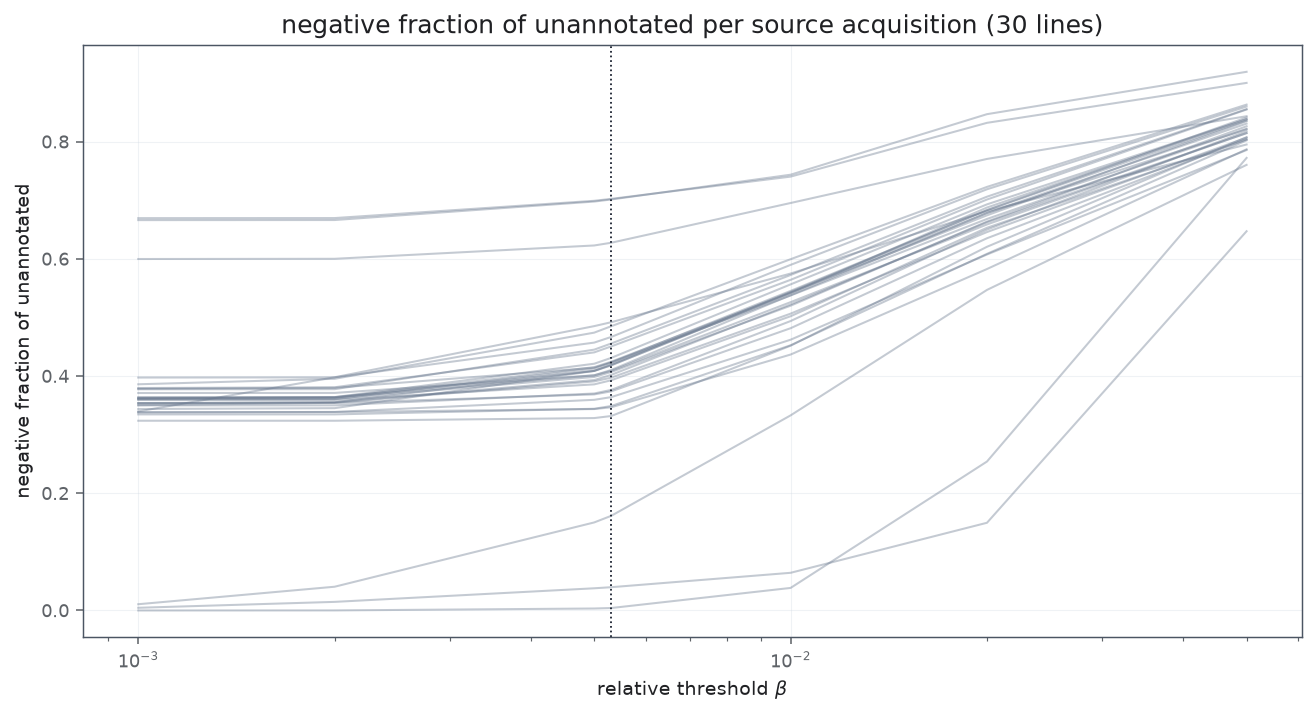

In [8]:
group_sweep = pd.DataFrame(thresholds.group_state_records(
    statistics, bin_radius=CONFIGURED_BIN_RADIUS,
    thresholds=sorted({*CANDIDATE_THRESHOLDS, SELECTED_THRESHOLD}),
))
group_sweep.to_csv(ARTIFACT_DIR / "acquisition_sweep.csv", index=False)

figure, axis = plt.subplots(figsize=(9.5, 5.2), dpi=theme.figure_dpi)
views.plot_group_stability(group_sweep.to_dict("records"), ax=axis, theme=theme)
axis.axvline(SELECTED_THRESHOLD, color=theme.baseline_color, linestyle=":",
             linewidth=theme.reference_line_width)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "acquisition_stability.png")

at_selected = group_sweep[np.isclose(group_sweep["relative_threshold"], SELECTED_THRESHOLD)]
display(at_selected.sort_values("negative_fraction_of_unannotated")[
    ["group", "pixels", "positive_entries", "negative_fraction_of_unannotated", "positive_contradiction_rate"]
].round(5))
print(f"negative yield across acquisitions at beta={SELECTED_THRESHOLD:.6g}: "
      f"min={at_selected['negative_fraction_of_unannotated'].min():.4f}, "
      f"median={at_selected['negative_fraction_of_unannotated'].median():.4f}, "
      f"max={at_selected['negative_fraction_of_unannotated'].max():.4f}")
print(f"contradiction rate across acquisitions: "
      f"min={at_selected['positive_contradiction_rate'].min():.4f}, "
      f"max={at_selected['positive_contradiction_rate'].max():.4f}")

## Do misalignment or bin sharing explain the ions with uninformative evidence?

### Methodology

#### Theoretical

`part_0_2` found 84 ions whose annotated pixels carry *less* signal at their own bin than
their unannotated ones ($\mathrm{AUC}_c < 0.5$). Two mechanisms measured in this
notebook and in `part_0_1` could produce that without any chemistry being involved, and
both are testable directly.

*Misalignment*: if an ion's peak sits consistently off the mapped bin, the evidence reads
a neighbouring position, and the correspondence with the annotation can degrade
arbitrarily. Prediction: low-AUC ions should be enriched among the ions with a nonzero
dominant displacement, and $\mathrm{AUC}_c$ should rise with `centre_share`.

*Bin sharing*: `part_0_1` established that 328 of 508 ion columns share a bin. When a
rare ion shares its bin with a prevalent one, its evidence is dominated by the other
ion's signal and need not track its own annotation at all. Prediction: low-AUC ions
should be enriched among bin-sharing ions, and, within a shared bin, the less prevalent
ions should have the lower AUC.

Both are stated as predictions before being checked, so that failing to find them is a
result rather than an absence of one.

#### Implementation

The per-ion separation table from `part_0_2` is joined to this notebook's per-ion
displacement table and to `part_0_1`'s prevalence table, all keyed by `class_name`. Bin
sharing is derived by grouping ions on their mapped bin centre. The comparison is
descriptive — group medians, enrichment against the base rate, and the Pearson
correlation between `centre_share` and $\mathrm{AUC}_c$ — because the three tables are
not independent samples and a formal test would overstate what a join of derived
quantities can support.

#### Figure descriptions

Two tables and no figure. The first compares ions with and without a nonzero dominant
displacement: their count, median $\mathrm{AUC}_c$, and how many fall below 0.5. The
second does the same split on whether the ion shares its bin, and then reports median
$\mathrm{AUC}_c$ by the ion's prevalence rank inside its shared bin, where rank 1 is the
most prevalent ion in that bin. Under either hypothesis the low-AUC ions would concentrate
in one group; comparable medians across groups mean the hypothesis fails.

### Remarks

### Notes

In [9]:
separation = pd.read_csv(
    "assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/"
    "part_0_2_evidence_threshold_selection_results/class_separation.csv"
)
prevalence = pd.read_csv(
    "assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/"
    "part_0_1_annotation_population_results/class_prevalence.csv"
)
joined = separation.merge(per_class[["class_name", "dominant_offset", "dominant_share", "centre_share"]],
                          on="class_name", how="left")
joined = joined.merge(prevalence[["class_name", "prevalence"]], on="class_name")
joined["off_centre"] = joined["dominant_offset"].fillna(0) != 0
joined["ions_in_bin"] = joined.groupby("bin_centre")["class_name"].transform("size")
joined["shares_bin"] = joined["ions_in_bin"] > 1
joined.to_csv(ARTIFACT_DIR / "separation_explanations.csv", index=False)

for column in ("off_centre", "shares_bin"):
    display(joined.groupby(column).agg(
        ions=("class_name", "size"),
        median_auc=("evidence_auc", "median"),
        ions_below_half=("evidence_auc", lambda values: int((values < 0.5).sum())),
        median_prevalence=("prevalence", "median"),
    ).round(4))

low = joined[joined["evidence_auc"] < 0.5]
print(f"ions with AUC < 0.5: {len(low)}")
print(f"  of which off-centre: {int(low['off_centre'].sum())} "
      f"(base rate {joined['off_centre'].mean():.0%})")
print(f"  of which sharing a bin: {int(low['shares_bin'].sum())} "
      f"(base rate {joined['shares_bin'].mean():.0%})")
print(f"correlation between centre_share and AUC: {joined['centre_share'].corr(joined['evidence_auc']):.4f}")

shared = joined[joined["shares_bin"]].copy()
shared["rank_in_bin"] = shared.groupby("bin_centre")["prevalence"].rank(ascending=False, method="min")
display(shared.groupby(shared["rank_in_bin"].clip(upper=4)).agg(
    ions=("class_name", "size"), median_auc=("evidence_auc", "median"),
).round(4))

,ions,median_auc,ions_below_half,median_prevalence
off_centre,,,,
False,361,0.7148,62,0.0174
True,147,0.7160,22,0.0237


,ions,median_auc,ions_below_half,median_prevalence
shares_bin,,,,
False,180,0.6886,21,0.0234
True,328,0.7318,63,0.0173


ions with AUC < 0.5: 84
  of which off-centre: 22 (base rate 29%)
  of which sharing a bin: 63 (base rate 65%)
correlation between centre_share and AUC: 0.0862


,ions,median_auc
rank_in_bin,,
1.0,119,0.7298
2.0,107,0.6819
3.0,45,0.6848
4.0,57,0.9146


## Results / Summary

### LLM

**Decisions supported by this notebook.** Keep `bin_radius: 1` and keep
`absolute_threshold: 0.0`. Both hold-fixed choices survive; the third — pooling over
acquisitions — does not, and it qualifies `part_0_2`'s recommendation rather than
overturning it.

**Observed results.**

- *Alignment.* Geometrically the mapping is sound: annotated m/z offsets from their bin
  centre are centred on zero (mean $-0.012$ bins) and bounded by half a bin, i.e. pure
  rounding. Empirically, displacement zero carries a clear excess over the unannotated
  null ($64.0\%$ against $39.9\%$, $+24.2$ points), confirming that the mapped bin is
  usually the peak-carrying one.
- *Radius.* At the configured $\beta = 0.005$ the contradiction rate falls monotonically
  with the radius (1.82 % / 0.85 % / 0.62 % for $\rho = 0/1/2$) while the yield falls too
  (35.6 % / 28.7 % / 22.8 %). At a matched 1 % tolerance the three are close (yields
  32.7 % / 29.3 % / 24.6 %), so $\rho = 1$ is a reasonable middle point but not a uniquely
  determined one.
- *Absolute floor.* The floor is inert or dominant with almost nothing in between: at the
  selected $\beta$, $\alpha \le 10^{-5}$ binds in no pixel, $10^{-4}$ in 1.5 % and
  $10^{-3}$ in 97.6 %. As a standalone rule it is near-equivalent to the relative one
  (27.4 % against 29.3 % yield at matched cost), so there is no yield argument for
  switching parameterization.

**Evidence of methodological problems, in decreasing severity.**

1. *The threshold's effect is not comparable across acquisitions.* At the selected
   $\beta$ the negative yield ranges from 0.42 % to 70.2 % across the 30 acquisitions.
   The two acquisitions producing almost no negatives are the two largest and hold 36.7 %
   of all pixels, so the pooled 29.3 % is not representative of a typical acquisition
   (about 41 %). Because the split assigns whole acquisitions, the train, validation and
   test partitions will contain materially different proportions of operational
   negatives, and any P/N or P/N/U metric compared across partitions is partly measuring
   which acquisitions landed where. The contradiction rate is similarly uneven — pooled
   0.96 %, but 4.83 % in the worst acquisition, five times the stated tolerance. This is a
   comparability problem for the campaign, not a reason to change $\beta$: no single
   threshold removes it.
2. *The relative rule is not scale-free.* Stratified by the pixel's own maximum, the
   negative yield at $\beta = 0.005$ runs from below $10^{-4}$ in pixels with a maximum
   under 0.03 to above 0.6 in pixels with a maximum above 0.2. Since the rule divides by
   that maximum precisely to remove pixel scale, this is a failure of its stated purpose:
   flat spectra receive essentially no negatives and peaky spectra receive nearly all of
   them. It is also the mechanism behind finding 1, since acquisitions differ in how
   peaked their spectra are.
3. *147 of 508 ions place their strongest bin dominantly off-centre*, some almost
   deterministically (`C19H22O4|-H` at $d = -2$ in 99.7 % of its informative entries with
   a centre share of zero). A radius of 1 does not reach $d = \pm 2$, so for those ions
   the configured rule reads a position the peak is never at. This is a per-ion labelling
   defect that the cohort-level alignment check does not reveal.

**A hypothesis that failed.** Neither mechanism explains the 84 ions with
$\mathrm{AUC}_c < 0.5$ from `part_0_2`. Off-centre and centred ions have the same median
AUC (0.716 against 0.715), and only 22 of the 84 low-AUC ions are off-centre — 26 %,
*below* the 29 % base rate rather than above it — with a correlation between
`centre_share` and AUC of 0.086. Bin sharing fares little better: 75 % of low-AUC ions
share a bin against a 65 % base rate, a mild enrichment rather than an explanation, and
median AUC by prevalence rank inside a shared bin is not monotone. The anti-correlation
between annotation and evidence for those 84 ions therefore remains unexplained by
anything measured here, and their operational negatives should be treated as
untrustworthy until it is.

**Limits.** The stratified and per-acquisition analyses are descriptive; no inferential
test is reported, because the strata and the acquisitions are neither independent nor
equally sized, and the effects above are large enough that a test would add nothing. The
alignment null is the unannotated displacement distribution, which is itself not uniform
(its own mode is at $d = 0$), so only the excess is interpreted, never the annotated
share alone.

### Person